# 07. RGB Backbone Deployability Benchmark

## 0. Setup

In [1]:
import csv
import random
import re
import json
import time
import math
import copy
import traceback
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
from torchvision.models import regnet_y_1_6gf, RegNet_Y_1_6GF_Weights
from torchvision.models import swin_t, Swin_T_Weights
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.checkpoint import checkpoint
from sklearn.metrics import (f1_score, roc_auc_score, mean_absolute_error, mean_squared_error)
import matplotlib.pyplot as plt

MANIFEST = Path('~/Desktop/convscript/Code/Manifest/manifests/master_manifest.csv').expanduser()
ROOT     = Path('~/Desktop/Thesis/TR-6').expanduser()
GAS_NORM = Path('~/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json').expanduser()
RUNS     = Path('~/Desktop/convscript/runs').expanduser()

DEVICE = (
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)
print(f'Device: {DEVICE}')

BENCH_OUT = RUNS / "07_backbone_benchmark"
BENCH_OUT.mkdir(parents=True, exist_ok=True)


Device: mps


## Data pipeline

In [2]:
FRUIT_LIST   = ['Banana', 'Carrot', 'Guava', 'Indian_Gooseberry', 'Mango', 'Tomato']
FRUIT_TO_IDX = {f: i for i, f in enumerate(FRUIT_LIST)}
SESSION_TO_IDX = {'morning': 0, 'afternoon': 1, 'evening': 2}
LABEL_TO_IDX   = {'not_spoiled': 0, 'spoiled': 1}
IMAGE_SIZE     = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]
SESSION_HOUR_BUCKETS = {'morning': (5, 11), 'afternoon': (12, 16), 'evening': (16, 19)}
IR_PATTERN   = re.compile(r'(\d{8})_(\d{6})_([\d.]+)C_([\d.]+)C\.jpg$', re.IGNORECASE)
SRGB_PATTERN = re.compile(r'^(\d{8})_(\d{6})[^/]*\.jpg$', re.IGNORECASE)
NUM_FRUITS   = len(FRUIT_TO_IDX)
THRESHOLDS_TO_SWEEP = [t / 100 for t in range(10, 91)]


def safe_float(val, default=0.0):
    try:
        return float(val)
    except Exception:
        return default


def hour_to_session(hour):
    for name, (lo, hi) in SESSION_HOUR_BUCKETS.items():
        if lo <= hour < hi:
            return name
    return 'unknown'


def find_ir_folder(base):
    for name in ['IR_fusion_images', 'IR_Fusion_images', 'ir_fusion_images']:
        p = base / name
        if p.exists():
            return p
    return base / 'IR_fusion_images'


def group_images_by_session(folder, pattern):
    result = defaultdict(lambda: defaultdict(list))
    if not folder.exists():
        return {}
    for f in sorted(folder.iterdir()):
        m = pattern.search(f.name)
        if not m:
            continue
        session = hour_to_session(int(m.group(2)[:2]))
        if session != 'unknown':
            result[m.group(1)][session].append(f)
    return dict(result)


def load_image(path, transform):
    return transform(Image.open(path).convert('RGB'))


def get_rgb_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def get_ir_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


In [3]:
class TrimodalDataset(Dataset):
    def __init__(self, manifest_path, root, train=True, modality_dropout_prob=0.3,
                 exclude_flagged=True, split=None, gas_norm_stats_path=None,
                 cache_images=True, shared_pixel_cache=None, gas_only=False):
        self.root = Path(root); self.train = train; self.modality_dropout_prob = modality_dropout_prob
        self.rgb_transform = get_rgb_transform(train); self.ir_transform = get_ir_transform(train)
        self.gas_norm_stats = None
        if gas_norm_stats_path:
            with open(gas_norm_stats_path) as f:
                self.gas_norm_stats = json.load(f)['stats']
            print(f'Gas norm stats loaded from {gas_norm_stats_path}')
        with open(manifest_path, newline='') as f:
            all_rows = list(csv.DictReader(f))
        if exclude_flagged:
            all_rows = [r for r in all_rows if r.get('exclude', '').strip().lower() != 'true']
        if split:
            all_rows = [r for r in all_rows if r.get('split', '').strip().lower() == split.lower()]
        self.samples = []; self._build_samples(all_rows)
        self.gas_only = gas_only; self._image_cache = {}
        if not gas_only:
            self._build_image_index()
        self._pixel_cache = {}
        if not gas_only:
            if shared_pixel_cache is not None:
                self._pixel_cache = shared_pixel_cache
                print(f'  Using shared image cache ({len(self._pixel_cache)} images).', flush=True)
            elif cache_images:
                self._warmup_pixel_cache()
        print(f'TrimodalDataset: {len(self.samples)} sessions '
              f'({"train" if train else "val/test"}, split={split})')

    def _build_samples(self, rows):
        for row in rows:
            fruit = row['fruit']; label = row['label']; date_str = row['actual_date']
            global_day = int(row['corrected_day_index'])
            days_until = safe_float(row.get('days_until_spoilage', ''), default=-1.0)
            for session in ['morning', 'afternoon', 'evening']:
                si = SESSION_TO_IDX[session]
                ir_avail = safe_float(row.get(f'ir_{session}_count', 0)) > 0
                ir_tmin = safe_float(row.get(f'ir_{session}_tmin', ''), 0.0)
                ir_tmax = safe_float(row.get(f'ir_{session}_tmax', ''), 0.0)
                ir_trange = safe_float(row.get(f'ir_{session}_trange', ''), 0.0)
                srgb_avail = safe_float(row.get(f'srgb_{session}_count', 0)) > 0
                gas_avail = row.get(f'methane_{session}_present', '').strip().upper() == 'TRUE'
                mean_ppm = safe_float(row.get(f'methane_{session}_ppm', ''), 0.0)
                std_ppm = safe_float(row.get(f'methane_{session}_std', ''), 0.0)
                left_ppm = safe_float(row.get(f'methane_{session}_left', ''), 0.0)
                right_ppm = safe_float(row.get(f'methane_{session}_right', ''), 0.0)
                if not ir_avail and not srgb_avail and not gas_avail:
                    continue
                self.samples.append({'fruit': fruit, 'label': label, 'actual_date': date_str,
                    'corrected_day_index': global_day, 'session': session, 'session_idx': si,
                    'fruit_idx': FRUIT_TO_IDX.get(fruit, 0), 'label_idx': LABEL_TO_IDX.get(label, 0),
                    'days_until_spoilage': days_until, 'ir_tmin': ir_tmin, 'ir_tmax': ir_tmax,
                    'ir_trange': ir_trange, 'gas_mean': mean_ppm, 'gas_std': std_ppm,
                    'gas_left': left_ppm, 'gas_right': right_ppm, 'gas_asym': abs(left_ppm - right_ppm),
                    'rgb_available': srgb_avail, 'ir_available': ir_avail, 'gas_available': gas_avail})

    def _build_image_index(self):
        label_map = {'not_spoiled': 'Not_spoiled', 'spoiled': 'Spoiled'}
        for fruit in FRUIT_LIST:
            for lk, lf in label_map.items():
                base = self.root / 'Classified' / fruit / lf
                for d, ss in group_images_by_session(base / 'sRGB_images', SRGB_PATTERN).items():
                    for s, ps in ss.items():
                        self._image_cache.setdefault((fruit, lk, d, s), {'rgb': [], 'ir': []})['rgb'] = ps
                for d, ss in group_images_by_session(find_ir_folder(base), IR_PATTERN).items():
                    for s, ps in ss.items():
                        self._image_cache.setdefault((fruit, lk, d, s), {'rgb': [], 'ir': []})['ir'] = ps
        banana_ir = group_images_by_session(find_ir_folder(self.root / 'Normal' / 'Banana'), IR_PATTERN)
        spoiled_dates = {date for (fr, lb, date, _) in self._image_cache if fr == 'Banana' and lb == 'spoiled'}
        for d, ss in banana_ir.items():
            if d in spoiled_dates:
                for s, ps in ss.items():
                    key = ('Banana', 'spoiled', d, s)
                    self._image_cache.setdefault(key, {'rgb': [], 'ir': []})
                    if not self._image_cache[key].get('ir'):
                        self._image_cache[key]['ir'] = ps

    def _load_cached(self, path, transform):
        cached = self._pixel_cache.get(str(path))
        if cached is not None:
            return transform(Image.fromarray(cached.permute(1, 2, 0).numpy()))
        return load_image(path, transform)

    def _warmup_pixel_cache(self):
        all_paths = set()
        for v in self._image_cache.values():
            all_paths.update(v.get('rgb', [])); all_paths.update(v.get('ir', []))
        total = len(all_paths)
        print(f'  Warming up image cache: {total} images...', flush=True)
        for i, path in enumerate(all_paths):
            if str(path) in self._pixel_cache:
                continue
            try:
                img = self.rgb_transform.transforms[0](Image.open(path).convert('RGB'))
                self._pixel_cache[str(path)] = torch.from_numpy(np.array(img)).permute(2, 0, 1)
            except Exception:
                pass
            if (i + 1) % 500 == 0 or (i + 1) == total:
                mb = sum(t.nbytes for t in self._pixel_cache.values()) / (1024 ** 2)
                print(f'  {i + 1}/{total} cached  ({mb:.0f} MB used)', flush=True)
        print(f'  Cache ready. {len(self._pixel_cache)} images in RAM.', flush=True)

    def _normalize_gas(self, fruit, session, mean_ppm, std_ppm, left_ppm, right_ppm):
        if self.gas_norm_stats is None:
            return mean_ppm, std_ppm, left_ppm, right_ppm
        s = self.gas_norm_stats.get(fruit, {}).get(session, {})

        def norm(val, key):
            st = s.get(key, {'mean': 0., 'std': 1.})
            return (val - st['mean']) / st['std']
        return norm(mean_ppm, 'mean_ppm'), norm(std_ppm, 'std_ppm'), norm(left_ppm, 'left_ppm'), norm(right_ppm, 'right_ppm')

    def _apply_dropout(self, rgb_avail, ir_avail, gas_avail):
        if not self.train:
            return rgb_avail, ir_avail, gas_avail
        while True:
            r = rgb_avail and (random.random() > self.modality_dropout_prob)
            i = ir_avail and (random.random() > self.modality_dropout_prob)
            g = gas_avail and (random.random() > self.modality_dropout_prob)
            if r or i or g:
                return r, i, g

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        fruit = s['fruit']; label = s['label']; date_str = s['actual_date']
        session = s['session']; si = s['session_idx']
        rgb_avail, ir_avail, gas_avail = self._apply_dropout(s['rgb_available'], s['ir_available'], s['gas_available'])
        cached = self._image_cache.get((fruit, label, date_str, session), {'rgb': [], 'ir': []})
        if not self.gas_only and rgb_avail and cached['rgb']:
            rgb_tensors = torch.stack([self._load_cached(p, self.rgb_transform) for p in cached['rgb']])
        else:
            rgb_avail = False; rgb_tensors = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
        if not self.gas_only and ir_avail and cached['ir']:
            ir_tensors = torch.stack([self._load_cached(p, self.ir_transform) for p in cached['ir']])
        else:
            ir_avail = False; ir_tensors = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
        ir_scalars = torch.tensor([s['ir_tmin'], s['ir_tmax'], s['ir_trange']], dtype=torch.float32) if ir_avail else torch.zeros(3)
        if gas_avail:
            m, sd, l, r = self._normalize_gas(fruit, session, s['gas_mean'], s['gas_std'], s['gas_left'], s['gas_right'])
            gas = torch.tensor([m, sd, l, r, abs(l - r), float(si) / 2.], dtype=torch.float32)
        else:
            gas = torch.zeros(6)
        return {'rgb_images': rgb_tensors, 'ir_images': ir_tensors, 'ir_scalars': ir_scalars, 'gas': gas,
                'rgb_available': torch.tensor(rgb_avail, dtype=torch.bool),
                'ir_available': torch.tensor(ir_avail, dtype=torch.bool),
                'gas_available': torch.tensor(gas_avail, dtype=torch.bool),
                'fruit_idx': torch.tensor(s['fruit_idx'], dtype=torch.long),
                'session_idx': torch.tensor(si, dtype=torch.long),
                'label': torch.tensor(s['label_idx'], dtype=torch.long),
                'days_until_spoilage': torch.tensor(s['days_until_spoilage'], dtype=torch.float32),
                'fruit': fruit, 'actual_date': date_str, 'corrected_day_index': s['corrected_day_index']}


In [4]:
class DayLevelSequenceDataset(Dataset):
    def __init__(self, manifest_path=MANIFEST, root=ROOT, split="train",
                 gas_norm_stats_path=GAS_NORM, shared_pixel_cache=None):
        base = TrimodalDataset(
            manifest_path, root, train=False, modality_dropout_prob=0.0,
            split=split, gas_norm_stats_path=gas_norm_stats_path, cache_images=True,
            shared_pixel_cache=shared_pixel_cache,
        )
        self._pixel_cache = base._pixel_cache
        print(f"DayLevelSequenceDataset ({split}): wrapping {len(base)} sessions")
        day_groups = defaultdict(list)
        for i in range(len(base)):
            item = base[i]
            key = (item["fruit"], int(item["label"].item()), int(item["corrected_day_index"]))
            day_groups[key].append(item)
        day_entries = {}
        for (fruit, label, day_idx), sessions in day_groups.items():
            sessions.sort(key=lambda s: int(s["session_idx"].item()))
            rgb_img, ir_img = None, None
            for s in sessions:
                if rgb_img is None and bool(s["rgb_available"].item()) and len(s["rgb_images"]) > 0:
                    rgb_img = s["rgb_images"][0]
                if ir_img is None and bool(s["ir_available"].item()) and len(s["ir_images"]) > 0:
                    ir_img = s["ir_images"][0]
            gas_vals = [s["gas"] for s in sessions if bool(s["gas_available"].item())]
            gas_avail = len(gas_vals) > 0
            gas_vec = torch.stack(gas_vals).mean(dim=0) if gas_avail else torch.zeros(6)
            day_entries.setdefault((fruit, label), []).append({
                "day_idx": day_idx, "rgb_img": rgb_img, "ir_img": ir_img,
                "gas_vec": gas_vec, "gas_avail": gas_avail,
                "fruit_idx": sessions[0]["fruit_idx"], "label": sessions[0]["label"],
                "days_until": sessions[0]["days_until_spoilage"],
            })
        self.trajectories = []
        for (fruit, label), days in day_entries.items():
            days.sort(key=lambda d: d["day_idx"])
            last_observed_idx = None
            for d in days:
                d["delta"] = 0.0 if last_observed_idx is None else float(d["day_idx"] - last_observed_idx)
                if d["gas_avail"]:
                    last_observed_idx = d["day_idx"]
            self.trajectories.append({"fruit": fruit, "label": label, "days": days})
        n_days_total = sum(len(t["days"]) for t in self.trajectories)
        print(f"  {len(self.trajectories)} trajectories, {n_days_total} total day-entries")

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]["days"]
        T = len(traj)
        blank_rgb = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        blank_ir = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        rgb_seq = torch.stack([d["rgb_img"] if d["rgb_img"] is not None else blank_rgb for d in traj])
        ir_seq = torch.stack([d["ir_img"] if d["ir_img"] is not None else blank_ir for d in traj])
        rgb_avail = torch.tensor([d["rgb_img"] is not None for d in traj], dtype=torch.bool)
        ir_avail = torch.tensor([d["ir_img"] is not None for d in traj], dtype=torch.bool)
        gas_seq = torch.stack([d["gas_vec"] for d in traj])
        gas_mask = torch.tensor([d["gas_avail"] for d in traj], dtype=torch.float32)
        gas_delta = torch.tensor([d["delta"] for d in traj], dtype=torch.float32)
        return {
            "rgb_seq": rgb_seq, "ir_seq": ir_seq, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas_seq, "gas_mask": gas_mask, "gas_delta": gas_delta, "T": T,
            "fruit_idx": traj[0]["fruit_idx"], "label": traj[-1]["label"],
            "days_until": traj[-1]["days_until"],
        }


def day_sequence_collate(batch):
    max_T = max(b["T"] for b in batch)
    B = len(batch)
    rgb = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    ir = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    rgb_avail = torch.zeros(B, max_T, dtype=torch.bool)
    ir_avail = torch.zeros(B, max_T, dtype=torch.bool)
    gas = torch.zeros(B, max_T, 6)
    gas_mask = torch.zeros(B, max_T)
    gas_delta = torch.zeros(B, max_T)
    pad_mask = torch.ones(B, max_T, dtype=torch.bool)
    fruit_idx = torch.zeros(B, dtype=torch.long)
    label = torch.zeros(B, dtype=torch.long)
    days_until = torch.zeros(B, dtype=torch.float32)
    for i, b in enumerate(batch):
        T = b["T"]
        rgb[i, :T] = b["rgb_seq"]; ir[i, :T] = b["ir_seq"]
        rgb_avail[i, :T] = b["rgb_avail"]; ir_avail[i, :T] = b["ir_avail"]
        gas[i, :T] = b["gas_seq"]; gas_mask[i, :T] = b["gas_mask"]; gas_delta[i, :T] = b["gas_delta"]
        pad_mask[i, :T] = False
        fruit_idx[i] = b["fruit_idx"]; label[i] = b["label"]; days_until[i] = b["days_until"]
    return {"rgb_seq": rgb, "ir_seq": ir, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas, "gas_mask": gas_mask, "gas_delta": gas_delta, "pad_mask": pad_mask,
            "fruit_idx": fruit_idx, "label": label, "days_until": days_until}


In [5]:
class OfflineAugmentedDayLevelSequenceDataset(Dataset):
    def __init__(self, base_dataset, transform_type="flip_rotation", n_copies=1):
        assert transform_type == "flip_rotation"
        self.base = base_dataset
        self.transform_type = transform_type
        self.n_copies = n_copies

        self.index_map = []
        for traj_idx in range(len(base_dataset)):
            self.index_map.append((traj_idx, 0))
            for copy_id in range(1, n_copies + 1):
                self.index_map.append((traj_idx, copy_id))

        self.trajectories = [base_dataset.trajectories[traj_idx] for traj_idx, _ in self.index_map]

        n_orig = len(base_dataset)
        print(f"OfflineAugmentedDayLevelSequenceDataset ({transform_type}, n_copies={n_copies}): "
              f"{n_orig} original trajectories -> {len(self)} total ({n_copies}x duplication)")

    def __len__(self):
        return len(self.index_map)

    def _augment_image(self, img, seed):
        g = torch.Generator().manual_seed(seed)
        out = torch.flip(img, dims=[-1])
        angle = (torch.rand(1, generator=g).item() * 30.0) - 15.0
        out = TF.rotate(out, angle)
        return out

    def __getitem__(self, idx):
        traj_idx, copy_id = self.index_map[idx]
        item = self.base[traj_idx]
        if copy_id == 0:
            return item

        seed_base = traj_idx * 10_000 + copy_id * 100
        item = dict(item)
        item["rgb_seq"] = torch.stack([
            self._augment_image(item["rgb_seq"][t], seed_base + t)
            for t in range(item["rgb_seq"].shape[0])
        ])
        item["ir_seq"] = torch.stack([
            self._augment_image(item["ir_seq"][t], seed_base + t)
            for t in range(item["ir_seq"].shape[0])
        ])
        return item


## Building blocks: CBAM, GRU-D

In [6]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(nn.Conv2d(channels, hidden, 1, bias=False), nn.ReLU(inplace=True),
                                  nn.Conv2d(hidden, channels, 1, bias=False))

    def forward(self, x):
        return torch.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out, _ = x.max(dim=1, keepdim=True)
        return torch.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = x * self.channel_attn(x)
        sa = self.spatial_attn(x)
        return x * sa, sa


class GRUDCell(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, x_mean=None):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        if x_mean is None:
            x_mean = [0.0] * input_dim
        self.register_buffer("x_mean", torch.as_tensor(x_mean, dtype=torch.float32))
        self.W_gamma_x = nn.Linear(1, input_dim)
        self.W_gamma_h = nn.Linear(1, hidden_dim)
        self.gru_cell = nn.GRUCell(input_dim * 2, hidden_dim)

    def forward(self, x_t, m_t, delta_t, x_last, h_prev):
        gamma_x = torch.exp(-torch.clamp(self.W_gamma_x(delta_t), min=0.0))
        x_bar = self.x_mean.unsqueeze(0).expand_as(x_t)
        x_hat = m_t * x_t + (1 - m_t) * (gamma_x * x_last + (1 - gamma_x) * x_bar)
        gamma_h = torch.exp(-torch.clamp(self.W_gamma_h(delta_t), min=0.0))
        h_t = self.gru_cell(torch.cat([x_hat, m_t], dim=-1), gamma_h * h_prev)
        return h_t, x_hat


class GasGRUDSequenceEncoder(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, x_mean=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = GRUDCell(input_dim, hidden_dim, x_mean)

    def forward(self, gas_seq, gas_mask, gas_delta, pad_mask):
        B, T, D = gas_seq.shape
        device = gas_seq.device
        h = torch.zeros(B, self.hidden_dim, device=device)
        x_last = torch.zeros(B, D, device=device)
        h_seq = []
        for t in range(T):
            x_t = gas_seq[:, t]
            m_t = gas_mask[:, t].unsqueeze(-1).expand(-1, D)
            delta_t = gas_delta[:, t].unsqueeze(-1)
            valid_t = (~pad_mask[:, t]).float().unsqueeze(-1)
            h_new, x_hat = self.cell(x_t, m_t, delta_t, x_last, h)
            h = valid_t * h_new + (1 - valid_t) * h
            x_last = torch.where(m_t.bool(), x_t, x_last)
            h_seq.append(h)
        return torch.stack(h_seq, dim=1)


## 1. RGB backbone candidates

In [7]:
BACKBONE_FEATURE_DIMS = {
    "efficientnet_b0": 1280,
    "resnet18": 512,
}


def _infer_feature_dim(backbone, img_size=IMAGE_SIZE):
    backbone.eval()
    with torch.no_grad():
        dummy = torch.zeros(1, 3, img_size, img_size)
        out = backbone(dummy)
    return out.shape[1]


def build_cnn_backbone(name: str):
    if name == "efficientnet_b0":
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        backbone = base.features
        return backbone, BACKBONE_FEATURE_DIMS[name]
    elif name == "resnet18":
        base = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        backbone = nn.Sequential(*list(base.children())[:-2])  
        return backbone, BACKBONE_FEATURE_DIMS[name]
    elif name == "convnext_tiny":
        base = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        backbone = base.features
    elif name == "mobilenet_v3_small":
        base = mobilenet_v3_small(weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1)
        backbone = base.features
    elif name == "efficientnet_v2_s":
        base = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        backbone = base.features
    elif name == "regnet_y_1_6gf":
        base = regnet_y_1_6gf(weights=RegNet_Y_1_6GF_Weights.IMAGENET1K_V1)
        backbone = nn.Sequential(base.stem, base.trunk_output)
    else:
        raise ValueError(
            f"Unknown plain-CNN backbone: {name}. Swin-Tiny and DINOv2 use their own "
            f"encoder classes (SwinCBAMEncoder, DINOv2Encoder) below, not build_cnn_backbone."
        )

    if name not in BACKBONE_FEATURE_DIMS:
        BACKBONE_FEATURE_DIMS[name] = _infer_feature_dim(backbone)
    return backbone, BACKBONE_FEATURE_DIMS[name]


## Visual encoder wrapper

In [8]:
class VisualEncoderToggle(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", freeze_backbone=True,
                 use_cbam=True, chunk_size=8):
        super().__init__()
        self.use_cbam = use_cbam
        self.backbone_name = backbone_name
        self.chunk_size = chunk_size
        self.backbone, self.feature_dim = build_cnn_backbone(backbone_name)
        if use_cbam:
            self.cbam = CBAM(self.feature_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def unfreeze_last_n_layers(self, n: int):
        self.freeze_backbone()
        for child in list(self.backbone.children())[-n:]:
            for p in child.parameters():
                p.requires_grad = True

    def forward(self, seq: torch.Tensor):
        B, T, C, H, W = seq.shape
        flat = seq.reshape(B * T, C, H, W)
        feats_list = []
        needs_ckpt = (torch.is_grad_enabled()
                      and any(p.requires_grad for p in self.backbone.parameters()))
        for start in range(0, flat.shape[0], self.chunk_size):
            chunk = flat[start:start + self.chunk_size]
            if needs_ckpt:
                feat_map = checkpoint(self.backbone, chunk, use_reentrant=False)
            else:
                feat_map = self.backbone(chunk)
            if self.use_cbam:
                feat_map, _ = self.cbam(feat_map)
            feats_list.append(self.pool(feat_map).flatten(1))
        feats = torch.cat(feats_list, dim=0).view(B, T, -1)
        return feats


## 2. Non-standard RGB encoders: Swin-Tiny, DINOv2

In [9]:
class SwinCBAMEncoder(nn.Module):
    def __init__(self, cbam_reduction=16, chunk_size=8):
        super().__init__()
        self.chunk_size = chunk_size
        base = swin_t(weights=Swin_T_Weights.IMAGENET1K_V1)
        self.backbone = base.features 
        self.feature_dim = _infer_feature_dim_channels_last(self.backbone)
        self.cbam = CBAM(self.feature_dim, reduction=cbam_reduction)
        self.pool = nn.AdaptiveAvgPool2d(1)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def unfreeze_last_n_layers(self, n: int):
        self.freeze_backbone()
        for child in list(self.backbone.children())[-n:]:
            for p in child.parameters():
                p.requires_grad = True

    def forward(self, seq: torch.Tensor):
        B, T, C, H, W = seq.shape
        flat = seq.reshape(B * T, C, H, W)
        needs_ckpt = (torch.is_grad_enabled()
                      and any(p.requires_grad for p in self.backbone.parameters()))
        feats_list = []
        for start in range(0, flat.shape[0], self.chunk_size):
            chunk = flat[start:start + self.chunk_size]
            if needs_ckpt:
                feat_map = checkpoint(self.backbone, chunk, use_reentrant=False)
            else:
                feat_map = self.backbone(chunk)
            feat_map = feat_map.permute(0, 3, 1, 2) 
            feat_map, _ = self.cbam(feat_map)
            feats_list.append(self.pool(feat_map).flatten(1))
        feats = torch.cat(feats_list, dim=0).view(B, T, -1)
        return feats


def _infer_feature_dim_channels_last(backbone, img_size=IMAGE_SIZE):
    backbone.eval()
    with torch.no_grad():
        dummy = torch.zeros(1, 3, img_size, img_size)
        out = backbone(dummy)  # (1,H,W,C)
    return out.shape[-1]


class DINOv2Encoder(nn.Module):
    def __init__(self, patch_size=14, cbam_reduction=16, chunk_size=8):
        super().__init__()
        self.patch_size = patch_size
        self.chunk_size = chunk_size
        self.dinov2 = torch.hub.load("facebookresearch/dinov2", "dinov2_vits14")
        for p in self.dinov2.parameters():
            p.requires_grad = False
        self.dinov2.eval()
        self.feature_dim = 384 
        self.cbam = CBAM(self.feature_dim, reduction=cbam_reduction)
        self.pool = nn.AdaptiveAvgPool2d(1)

    def freeze_backbone(self):
        pass 

    def unfreeze_backbone(self):
        pass  

    def unfreeze_last_n_layers(self, n: int):
        pass 

    def forward(self, seq: torch.Tensor):
        B, T, C, H, W = seq.shape
        flat = seq.reshape(B * T, C, H, W)
        n_side = H // self.patch_size  

        feats_list = []
        for start in range(0, flat.shape[0], self.chunk_size):
            chunk = flat[start:start + self.chunk_size]
            with torch.no_grad():
                out = self.dinov2.forward_features(chunk)
                tokens = out["x_norm_patchtokens"] 
            grid = tokens.permute(0, 2, 1).reshape(-1, self.feature_dim, n_side, n_side)
            grid, _ = self.cbam(grid)  
            feats_list.append(self.pool(grid).flatten(1))
        feats = torch.cat(feats_list, dim=0).view(B, T, -1)
        return feats


print("SwinCBAMEncoder, DINOv2Encoder ready.")


SwinCBAMEncoder, DINOv2Encoder ready.


## 3. Fusion, temporal model, loss

In [10]:
class CrossModalFusion(nn.Module):
    def __init__(self, d_model=64, num_heads=4, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads,
                                           dropout=dropout, batch_first=True)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, rgb_t, ir_t, gas_t, rgb_avail_t, ir_avail_t, gas_avail_t):
        tokens = torch.stack([rgb_t, ir_t, gas_t], dim=1)
        avail = torch.stack([rgb_avail_t, ir_avail_t, gas_avail_t], dim=1)
        key_padding_mask = ~avail
        fully_missing = key_padding_mask.all(dim=1)
        if fully_missing.any():
            key_padding_mask = key_padding_mask.clone()
            key_padding_mask[fully_missing] = False
        attended, attn_w = self.attn(tokens, tokens, tokens, key_padding_mask=key_padding_mask,
                                      need_weights=True, average_attn_weights=True)
        out = self.norm(tokens + attended)
        return out.mean(dim=1), attn_w


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.shape[1]]


class TemporalTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, dim_feedforward=512,
                 dropout=0.1, max_len=100):
        super().__init__()
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
                                            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, z_seq: torch.Tensor, pad_mask: torch.Tensor):
        z_seq = self.pos_enc(z_seq)
        return self.encoder(z_seq, src_key_padding_mask=pad_mask)


def gather_last_valid(H: torch.Tensor, pad_mask: torch.Tensor):
    device = H.device
    lengths = (~pad_mask).sum(dim=1)
    last_idx = (lengths - 1).clamp(min=0)
    B = H.shape[0]
    return H[torch.arange(B, device=device), last_idx], last_idx


class UncertaintyWeightedLoss(nn.Module):
    def __init__(self, n_tasks: int = 3):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.zeros(n_tasks))

    def forward(self, losses: list):
        total = 0.0
        for i, L_i in enumerate(losses):
            precision = torch.exp(-2 * self.log_sigma[i])
            total = total + 0.5 * precision * L_i + self.log_sigma[i]
        return total

    def get_sigmas(self):
        return torch.exp(self.log_sigma).detach().cpu().numpy()


## 4. The trimodal fusion model with a swappable RGB encoder

In [11]:
class TrimodalFusionModel(nn.Module):
    def __init__(self, rgb_backbone_name="convnext_tiny", ir_backbone_name="efficientnet_b0",
                 d_model=64, gas_hidden=64, num_heads=4, temporal_layers=2,
                 dropout=0.5, cls_dropout=0.5, freeze_visual_backbone=True):
        super().__init__()
        self.d_model = d_model
        self.rgb_backbone_name = rgb_backbone_name
        self.ir_backbone_name = ir_backbone_name

        self.rgb_encoder = VisualEncoderToggle(rgb_backbone_name, freeze_visual_backbone, use_cbam=True)
        self.ir_encoder = VisualEncoderToggle(ir_backbone_name, freeze_visual_backbone, use_cbam=True)
        self.gas_encoder = GasGRUDSequenceEncoder(input_dim=6, hidden_dim=gas_hidden)

        self.rgb_proj = nn.Sequential(nn.Linear(self.rgb_encoder.feature_dim, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.ir_proj = nn.Sequential(nn.Linear(self.ir_encoder.feature_dim, d_model),
                                      nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.gas_proj = nn.Sequential(nn.Linear(gas_hidden, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))

        self.fusion = CrossModalFusion(d_model=d_model, num_heads=num_heads, dropout=dropout)
        self.temporal = TemporalTransformer(d_model=d_model, nhead=num_heads,
                                             num_layers=temporal_layers, dropout=dropout)

        self.cls_head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(),
                                       nn.Dropout(cls_dropout), nn.Linear(128, 2))
        self.reg_head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(),
                                       nn.Dropout(cls_dropout), nn.Linear(128, 1), nn.ReLU())
        self.gas_recon_head = nn.Sequential(nn.Linear(d_model * 2, 128), nn.ReLU(),
                                             nn.Dropout(cls_dropout), nn.Linear(128, 6))

    def freeze_visual_backbones(self):
        self.rgb_encoder.freeze_backbone(); self.ir_encoder.freeze_backbone()

    def unfreeze_visual_last_n(self, n: int):
        self.rgb_encoder.unfreeze_last_n_layers(n)
        self.ir_encoder.unfreeze_last_n_layers(n)

    def unfreeze_visual_full(self):
        self.rgb_encoder.unfreeze_backbone()
        self.ir_encoder.unfreeze_backbone()

    def forward(self, batch: dict):
        device = next(self.parameters()).device
        rgb_seq = batch["rgb_seq"].to(device); ir_seq = batch["ir_seq"].to(device)
        rgb_avail = batch["rgb_avail"].to(device); ir_avail = batch["ir_avail"].to(device)
        gas_seq = batch["gas_seq"].to(device); gas_mask = batch["gas_mask"].to(device)
        gas_delta = batch["gas_delta"].to(device); pad_mask = batch["pad_mask"].to(device)
        B, T = rgb_avail.shape

        rgb_feat = self.rgb_encoder(rgb_seq)
        ir_feat = self.ir_encoder(ir_seq)
        gas_feat = self.gas_encoder(gas_seq, gas_mask, gas_delta, pad_mask)

        rgb_proj = self.rgb_proj(rgb_feat) * rgb_avail.unsqueeze(-1).float()
        ir_proj = self.ir_proj(ir_feat) * ir_avail.unsqueeze(-1).float()
        gas_proj = self.gas_proj(gas_feat) * gas_mask.unsqueeze(-1)

        rgb_flat = rgb_proj.reshape(B * T, -1)
        ir_flat = ir_proj.reshape(B * T, -1)
        gas_flat = gas_proj.reshape(B * T, -1)
        rgb_av_flat = rgb_avail.reshape(B * T)
        ir_av_flat = ir_avail.reshape(B * T)
        gas_av_flat = gas_mask.reshape(B * T).bool()
        z_flat, _ = self.fusion(rgb_flat, ir_flat, gas_flat, rgb_av_flat, ir_av_flat, gas_av_flat)
        z_seq = z_flat.reshape(B, T, -1)

        H = self.temporal(z_seq, pad_mask)
        H_T, last_idx = gather_last_valid(H, pad_mask)
        cls_logits = self.cls_head(H_T)
        reg_output = self.reg_head(H_T)

        rgb_last = rgb_proj[torch.arange(B, device=device), last_idx]
        ir_last = ir_proj[torch.arange(B, device=device), last_idx]
        gas_recon = self.gas_recon_head(torch.cat([rgb_last, ir_last], dim=1))

        return {"cls_logits": cls_logits, "reg_output": reg_output, "gas_recon": gas_recon, "last_idx": last_idx}


class FusionModelCustomRGB(TrimodalFusionModel):
    def __init__(self, rgb_encoder_factory, **kwargs):
        kwargs.setdefault("rgb_backbone_name", "efficientnet_b0")  
        super().__init__(**kwargs)
        d_model = self.d_model
        dropout = kwargs.get("dropout", 0.5)
        self.rgb_encoder = rgb_encoder_factory()
        self.rgb_proj = nn.Sequential(
            nn.Linear(self.rgb_encoder.feature_dim, d_model),
            nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout),
        )

    def unfreeze_visual_last_n(self, n: int):
        self.rgb_encoder.unfreeze_last_n_layers(n)
        self.ir_encoder.unfreeze_last_n_layers(n)

    def unfreeze_visual_full(self):
        self.rgb_encoder.unfreeze_backbone()
        self.ir_encoder.unfreeze_backbone()

## 5. Architecture profiling helper

In [12]:
def estimate_backbone_flops(model, sample_batch, device, n_warmup=3, n_timed=10):
    profile_copy = copy.deepcopy(model).to(device)
    profile_copy.eval()

    n_params = sum(p.numel() for p in profile_copy.parameters())

    flops_g = None
    try:
        from thop import profile as thop_profile
        with torch.no_grad():
            macs, _ = thop_profile(profile_copy, inputs=(sample_batch,), verbose=False)
        flops_g = round(macs * 2 / 1e9, 3)
    except ImportError:
        print("  [WARN] thop not installed - FLOPs not measured for this candidate "
              "(pip install thop to enable).")
    except Exception as e:
        print(f"  [WARN] FLOPs profiling failed: {type(e).__name__}: {e}")

    latency_ms = None
    try:
        with torch.no_grad():
            for _ in range(n_warmup):
                profile_copy(sample_batch)
            if device == "cuda":
                torch.cuda.synchronize()
            start = time.perf_counter()
            for _ in range(n_timed):
                profile_copy(sample_batch)
            if device == "cuda":
                torch.cuda.synchronize()
        latency_ms = round((time.perf_counter() - start) / n_timed * 1000, 1)
    except Exception as e:
        print(f"  [WARN] Latency profiling failed: {type(e).__name__}: {e}")

    del profile_copy
    return {"params_m": round(n_params / 1e6, 2), "flops_g": flops_g, "latency_ms": latency_ms}


## 6. Training / evaluation helpers

In [13]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def build_weighted_sampler(dataset):
    labels = [int(t["label"]) for t in dataset.trajectories]
    n_total = len(labels); n_spoiled = max(sum(labels), 1); n_fresh = max(n_total - sum(labels), 1)
    w_spoiled = n_total / (2 * n_spoiled); w_fresh = n_total / (2 * n_fresh)
    weights = [w_spoiled if l == 1 else w_fresh for l in labels]
    return WeightedRandomSampler(weights=weights, num_samples=n_total, replacement=True)


def calibrate_threshold(scores, labels, thresholds=None):
    if thresholds is None:
        thresholds = THRESHOLDS_TO_SWEEP
    if len(set(labels)) < 2:
        return 0.5, 0.0
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = [1 if s >= t else 0 for s in scores]
        f = f1_score(labels, preds, average="binary", zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


def compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred):
    f1 = f1_score(all_labels, all_preds, average="binary", zero_division=0)
    try:
        auc = roc_auc_score(all_labels, np.array(all_probs)[:, 1])
    except ValueError:
        auc = float("nan")
    mae = mean_absolute_error(all_days_gt, all_days_pred)
    rmse = mean_squared_error(all_days_gt, all_days_pred) ** 0.5
    return {"f1": round(f1, 4), "auc": round(auc, 4), "mae": round(mae, 4), "rmse": round(rmse, 4)}


def compute_loss(out, batch, uncertainty_loss, cfg, device):
    labels = batch["label"].to(device)
    days = batch["days_until"].to(device)
    class_weights = torch.tensor(cfg["cls_class_weights"], device=device)

    cls_loss = nn.CrossEntropyLoss(weight=class_weights)(out["cls_logits"], labels)
    reg_loss = nn.SmoothL1Loss()(out["reg_output"].squeeze(1), days)

    pad_mask = batch["pad_mask"].to(device)
    gas_mask = batch["gas_mask"].to(device)
    gas_seq = batch["gas_seq"].to(device)
    last_idx = out["last_idx"]
    B = labels.shape[0]
    gas_avail_last = gas_mask[torch.arange(B, device=device), last_idx].bool()
    gas_true_last = gas_seq[torch.arange(B, device=device), last_idx]

    if gas_avail_last.any():
        recon_loss = nn.MSELoss()(out["gas_recon"][gas_avail_last], gas_true_last[gas_avail_last])
    else:
        recon_loss = torch.zeros((), device=device)

    total_loss = uncertainty_loss([cls_loss, reg_loss, recon_loss])
    return total_loss, {"cls_loss": cls_loss.item(), "reg_loss": reg_loss.item(), "recon_loss": recon_loss.item()}


def collect_probs_labels(model, uncertainty_loss, loader, cfg):
    model.eval(); uncertainty_loss.eval()
    device = cfg["device"]
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            out = model(batch)
            probs = torch.softmax(out["cls_logits"], dim=1).cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            all_days_pred.extend(out["reg_output"].squeeze(1).cpu().numpy().tolist())
    return np.array(all_probs), all_labels, all_days_gt, all_days_pred


def get_calibrated_threshold(model, uncertainty_loss, calib_loader, cfg):
    probs, labels, _, _ = collect_probs_labels(model, uncertainty_loss, calib_loader, cfg)
    threshold, _ = calibrate_threshold(probs[:, 1].tolist(), labels)
    return threshold


def run_epoch(model, uncertainty_loss, loader, optimizer, cfg, train=True, threshold=None):
    model.train() if train else model.eval()
    uncertainty_loss.train() if train else uncertainty_loss.eval()
    device = cfg["device"]
    total_loss = 0.0
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            out = model(batch)
            loss, parts = compute_loss(out, batch, uncertainty_loss, cfg, device)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(list(model.parameters()) + list(uncertainty_loss.parameters()), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            probs = torch.softmax(out["cls_logits"], dim=1).detach().cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            all_days_pred.extend(out["reg_output"].squeeze(1).detach().cpu().numpy().tolist())

    all_probs_arr = np.array(all_probs)
    if train:
        all_preds = all_probs_arr.argmax(axis=1).tolist()
        threshold_used = 0.5
    else:
        if threshold is None:
            raise ValueError("run_epoch(train=False) requires a pre-calibrated threshold; "
                              "never self-calibrates on the set it is about to score.")
        threshold_used = threshold
        all_preds = (all_probs_arr[:, 1] >= threshold_used).astype(int).tolist()

    metrics = compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred)
    metrics["loss"] = round(total_loss / max(len(loader), 1), 4)
    metrics["threshold"] = threshold_used
    return metrics


def get_cfg():
    return {
        "epochs": 30, "batch_size": 4, "lr": 1e-4, "lr_finetune": 1e-5, "weight_decay": 1e-4,
        "cls_class_weights": [1.0, 2.3], "device": DEVICE,
    }


## 7. Data

In [14]:
cfg = get_cfg()
D_MODEL, DROPOUT = 64, 0.5
AUGMENTATION_TRANSFORM = "flip_rotation"
N_COPIES = 1
SEEDS = list(range(10))

train_ds_base = DayLevelSequenceDataset(split="train")
val_ds = DayLevelSequenceDataset(split="val", shared_pixel_cache=train_ds_base._pixel_cache)
train_ds = OfflineAugmentedDayLevelSequenceDataset(train_ds_base, AUGMENTATION_TRANSFORM, N_COPIES)

train_sampler = build_weighted_sampler(train_ds)
train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], sampler=train_sampler,
                           collate_fn=day_sequence_collate, num_workers=0)
train_loader_calib = DataLoader(train_ds_base, batch_size=cfg["batch_size"], shuffle=False,
                                 collate_fn=day_sequence_collate, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False,
                         collate_fn=day_sequence_collate, num_workers=0)

sample_batch = next(iter(val_loader))
print(f"train: {len(train_ds)} trajectories (incl. augmentation) | "
      f"calib: {len(train_ds_base)} | val: {len(val_ds)}")


Gas norm stats loaded from /Users/sjanani2073/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json
  Warming up image cache: 10983 images...
  500/10983 cached  (72 MB used)
  1000/10983 cached  (144 MB used)
  1500/10983 cached  (215 MB used)
  2000/10983 cached  (287 MB used)
  2500/10983 cached  (359 MB used)
  3000/10983 cached  (431 MB used)
  3500/10983 cached  (502 MB used)
  4000/10983 cached  (574 MB used)
  4500/10983 cached  (646 MB used)
  5000/10983 cached  (718 MB used)
  5500/10983 cached  (790 MB used)
  6000/10983 cached  (861 MB used)
  6500/10983 cached  (933 MB used)
  7000/10983 cached  (1005 MB used)
  7500/10983 cached  (1077 MB used)
  8000/10983 cached  (1148 MB used)
  8500/10983 cached  (1220 MB used)
  9000/10983 cached  (1292 MB used)
  9500/10983 cached  (1364 MB used)
  10000/10983 cached  (1436 MB used)
  10500/10983 cached  (1507 MB used)
  10983/10983 cached  (1577 MB used)
  Cache ready. 10983 images in RAM.
TrimodalDataset: 212 sessions (val/

## 8. 8 RGB-encoder candidates

In [15]:
CANDIDATES = {
    "resnet18": {
        "label": "ResNet-18",
        "factory": lambda: VisualEncoderToggle("resnet18", freeze_backbone=True, use_cbam=True),
    },
    "efficientnet_b0": {
        "label": "EfficientNet-B0",
        "factory": lambda: VisualEncoderToggle("efficientnet_b0", freeze_backbone=True, use_cbam=True),
    },
    "mobilenet_v3_small": {
        "label": "MobileNetV3-Small",
        "factory": lambda: VisualEncoderToggle("mobilenet_v3_small", freeze_backbone=True, use_cbam=True),
    },
    "convnext_tiny": {
        "label": "ConvNeXt-Tiny (chosen backbone)",
        "factory": lambda: VisualEncoderToggle("convnext_tiny", freeze_backbone=True, use_cbam=True),
    },
    "efficientnet_v2_s": {
        "label": "EfficientNetV2-S",
        "factory": lambda: VisualEncoderToggle("efficientnet_v2_s", freeze_backbone=True, use_cbam=True),
    },
    "regnet_y_1_6gf": {
        "label": "RegNetY-1.6GF",
        "factory": lambda: VisualEncoderToggle("regnet_y_1_6gf", freeze_backbone=True, use_cbam=True),
    },
    "swin_tiny": {
        "label": "Swin-Tiny",
        "factory": lambda: SwinCBAMEncoder(),
    },
    "dinov2": {
        "label": "DINOv2 (ViT-S/14, frozen)",
        "factory": lambda: DINOv2Encoder(),
    },
}

CANDIDATE_ORDER = list(CANDIDATES.keys())
print(f"{len(CANDIDATES)} candidates: {CANDIDATE_ORDER}")


8 candidates: ['resnet18', 'efficientnet_b0', 'mobilenet_v3_small', 'convnext_tiny', 'efficientnet_v2_s', 'regnet_y_1_6gf', 'swin_tiny', 'dinov2']


## 9. Training loop 

In [16]:
def get_backbone_only_params(encoder):
    if hasattr(encoder, "backbone"):
        return list(encoder.backbone.parameters())
    if hasattr(encoder, "dinov2"):
        return list(encoder.dinov2.parameters())
    return []


def train_one_candidate_seed(cand_key, seed, seed_num, n_seeds, out_dir):
    set_seed(seed)
    label = CANDIDATES[cand_key]["label"]
    run_dir = out_dir / cand_key / f"seed_{seed}"
    run_dir.mkdir(parents=True, exist_ok=True)

    model = FusionModelCustomRGB(
        rgb_encoder_factory=CANDIDATES[cand_key]["factory"],
        ir_backbone_name="efficientnet_b0",
        d_model=D_MODEL, dropout=DROPOUT, cls_dropout=DROPOUT,
        freeze_visual_backbone=True,
    ).to(cfg["device"])
    uncertainty_loss = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])

    rgb_backbone_params = get_backbone_only_params(model.rgb_encoder)
    ir_backbone_params = get_backbone_only_params(model.ir_encoder)
    backbone_ids = {id(p) for p in rgb_backbone_params + ir_backbone_params}
    other_params = [p for p in model.parameters() if id(p) not in backbone_ids]

    param_groups = [{"params": other_params, "lr": cfg["lr"]},
                     {"params": list(uncertainty_loss.parameters()), "lr": cfg["lr"]}]
    if rgb_backbone_params:
        param_groups.append({"params": rgb_backbone_params, "lr": cfg["lr_finetune"]})
    if ir_backbone_params:
        param_groups.append({"params": ir_backbone_params, "lr": cfg["lr_finetune"]})
    optimizer = AdamW(param_groups, weight_decay=cfg["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg["epochs"])

    print(f"{'-' * 90}")
    print(f"[{label}] seed {seed} ({seed_num}/{n_seeds}) -- {cfg['epochs']} epochs, "
          f"trained on train ({len(train_loader.dataset)} trajectories incl. augmentation), "
          f"validated on held-out val ({len(val_loader.dataset)} trajectories)")
    print(f"{'-' * 90}")

    history = []
    best_val_f1, best_metrics = -1.0, None
    run_start = time.time()
    for epoch in range(1, cfg["epochs"] + 1):
        epoch_start = time.time()
        unfreeze_note = ""
        if epoch == 6:
            model.unfreeze_visual_last_n(1); unfreeze_note = "  [unfreeze last-1]"
        elif epoch == 8:
            model.unfreeze_visual_last_n(2); unfreeze_note = "  [unfreeze last-2]"
        elif epoch == 12:
            model.unfreeze_visual_full(); unfreeze_note = "  [unfreeze full]"

        train_m = run_epoch(model, uncertainty_loss, train_loader, optimizer, cfg, train=True)
        scheduler.step()

        thr = get_calibrated_threshold(model, uncertainty_loss, train_loader_calib, cfg)
        val_m = run_epoch(model, uncertainty_loss, val_loader, optimizer, cfg, train=False, threshold=thr)
        epoch_time = time.time() - epoch_start

        is_best = val_m["f1"] > best_val_f1
        if is_best:
            best_val_f1 = val_m["f1"]
            best_metrics = val_m

        history.append({
            "epoch": epoch, "train_loss": train_m["loss"], "train_f1": train_m["f1"],
            "val_f1": val_m["f1"], "val_auc": val_m["auc"], "val_mae": val_m["mae"],
            "val_threshold": thr, "lr": optimizer.param_groups[0]["lr"],
            "epoch_time_s": round(epoch_time, 1),
        })

        print(f"  [{cand_key}] seed {seed} | epoch {epoch:2d}/{cfg['epochs']} | "
              f"train_loss={train_m['loss']:.4f} train_F1={train_m['f1']:.3f} | "
              f"val_F1={val_m['f1']:.3f} val_AUC={val_m['auc']:.3f} val_MAE={val_m['mae']:.2f} "
              f"thr={thr:.2f}{'  *NEW BEST*' if is_best else ''} | {epoch_time:.1f}s{unfreeze_note}")

    total_time = time.time() - run_start
    with open(run_dir / "history.json", "w") as f:
        json.dump(history, f, indent=2, default=str)

    print(f"  [{cand_key} seed={seed}] DONE in {total_time / 60:.1f} min -- "
          f"BEST val F1={best_metrics['f1']:.4f} AUC={best_metrics['auc']:.4f}")

    return model, {"seed": seed, "val_f1": best_metrics["f1"], "val_auc": best_metrics["auc"],
                    "val_mae": best_metrics["mae"], "history": history, "total_time_s": round(total_time, 1)}


In [17]:
RESULTS = {}    
FAILURES = []    
for cand_key in CANDIDATE_ORDER:
    label = CANDIDATES[cand_key]["label"]
    print(f"\n{'=' * 90}\n CANDIDATE: {label}  ({cand_key})\n{'=' * 90}")

    seed_results = []
    profile = None

    try:
        set_seed(SEEDS[0])
        probe_model = FusionModelCustomRGB(
            rgb_encoder_factory=CANDIDATES[cand_key]["factory"],
            ir_backbone_name="efficientnet_b0",
            d_model=D_MODEL, dropout=DROPOUT, cls_dropout=DROPOUT,
            freeze_visual_backbone=True,
        ).to(cfg["device"])
        profile = estimate_backbone_flops(probe_model, sample_batch, cfg["device"])
        del probe_model
        print(f"  [{cand_key}] profile: {profile}")
    except Exception as e:
        tb = traceback.format_exc()
        print(f"  [FAIL] [{cand_key}] profiling failed: {type(e).__name__}: {e}\n{tb}")
        FAILURES.append({"candidate": cand_key, "seed": None, "stage": "profiling",
                          "type": type(e).__name__, "message": str(e), "traceback": tb})

    for seed_num, seed in enumerate(SEEDS, start=1):
        try:
            model, res = train_one_candidate_seed(cand_key, seed, seed_num, len(SEEDS), BENCH_OUT)
            seed_results.append(res)
            del model
        except Exception as e:
            tb = traceback.format_exc()
            print(f"  [FAIL] [{cand_key}] seed {seed} training failed: {type(e).__name__}: {e}\n{tb}")
            FAILURES.append({"candidate": cand_key, "seed": seed, "stage": "training",
                              "type": type(e).__name__, "message": str(e), "traceback": tb})

    RESULTS[cand_key] = {"seed_results": seed_results, "profile": profile}

print(f"\n{'=' * 90}\nAll candidates attempted. {len(FAILURES)} failure(s) recorded.\n{'=' * 90}")
if FAILURES:
    for fail in FAILURES:
        print(f"  - {fail['candidate']} (seed {fail['seed']}, {fail['stage']}): "
              f"{fail['type']}: {fail['message']}")



 CANDIDATE: ResNet-18  (resnet18)


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_19646/1633675894.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  [resnet18] profile: {'params_m': 15.77, 'flops_g': 17.906, 'latency_ms': 17.2}
------------------------------------------------------------------------------------------
[ResNet-18] seed 0 (1/10) -- 30 epochs, trained on train (24 trajectories incl. augmentation), validated on held-out val (12 trajectories)
------------------------------------------------------------------------------------------
  [resnet18] seed 0 | epoch  1/30 | train_loss=2.5474 train_F1=0.417 | val_F1=0.667 val_AUC=0.694 val_MAE=2.17 thr=0.46  *NEW BEST* | 3.6s
  [resnet18] seed 0 | epoch  2/30 | train_loss=2.4928 train_F1=0.571 | val_F1=0.667 val_AUC=0.444 val_MAE=2.17 thr=0.44 | 2.3s
  [resnet18] seed 0 | epoch  3/30 | train_loss=1.9272 train_F1=0.788 | val_F1=0.667 val_AUC=0.500 val_MAE=2.17 thr=0.41 | 2.4s
  [resnet18] seed 0 | epoch  4/30 | train_loss=1.4611 train_F1=0.800 | val_F1=0.667 val_AUC=0.500 val_MAE=2.17 thr=0.57 | 2.1s
  [resnet18] seed 0 | epoch  5/30 | train_loss=1.6964 train_F1=0.727 | val_F1=

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_19646/1633675894.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


------------------------------------------------------------------------------------------
[ResNet-18] seed 1 (2/10) -- 30 epochs, trained on train (24 trajectories incl. augmentation), validated on held-out val (12 trajectories)
------------------------------------------------------------------------------------------
  [resnet18] seed 1 | epoch  1/30 | train_loss=2.2204 train_F1=0.400 | val_F1=0.667 val_AUC=0.722 val_MAE=2.18 thr=0.35  *NEW BEST* | 1.9s
  [resnet18] seed 1 | epoch  2/30 | train_loss=2.5202 train_F1=0.273 | val_F1=0.667 val_AUC=0.556 val_MAE=2.15 thr=0.10 | 2.9s
  [resnet18] seed 1 | epoch  3/30 | train_loss=2.3093 train_F1=0.621 | val_F1=0.667 val_AUC=0.694 val_MAE=2.18 thr=0.10 | 3.0s
  [resnet18] seed 1 | epoch  4/30 | train_loss=2.7429 train_F1=0.273 | val_F1=0.667 val_AUC=0.500 val_MAE=2.18 thr=0.10 | 2.6s
  [resnet18] seed 1 | epoch  5/30 | train_loss=1.4834 train_F1=0.667 | val_F1=0.667 val_AUC=0.417 val_MAE=2.18 thr=0.44 | 1.3s
  [resnet18] seed 1 | epoch  6/3

...

------------------------------------------------------------------------------------------
[DINOv2 (ViT-S/14, frozen)] seed 7 (8/10) -- 30 epochs, trained on train (24 trajectories incl. augmentation), validated on held-out val (12 trajectories)
------------------------------------------------------------------------------------------
  [dinov2] seed 7 | epoch  1/30 | train_loss=1.5745 train_F1=0.353 | val_F1=0.588 val_AUC=0.500 val_MAE=2.18 thr=0.50  *NEW BEST* | 4.9s
  [dinov2] seed 7 | epoch  2/30 | train_loss=2.2958 train_F1=0.462 | val_F1=0.625 val_AUC=0.444 val_MAE=2.16 thr=0.55  *NEW BEST* | 7.2s
  [dinov2] seed 7 | epoch  3/30 | train_loss=3.0651 train_F1=0.400 | val_F1=0.667 val_AUC=0.667 val_MAE=2.19 thr=0.59  *NEW BEST* | 10.3s
  [dinov2] seed 7 | epoch  4/30 | train_loss=2.6818 train_F1=0.320 | val_F1=0.667 val_AUC=0.611 val_MAE=2.16 thr=0.57 | 9.6s
  [dinov2] seed 7 | epoch  5/30 | train_loss=2.8897 train_F1=0.615 | val_F1=0.667 val_AUC=0.611 val_MAE=2.19 thr=0.61 | 10.5s


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_19646/1633675894.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
Using cache found in /Users/sjanani2073/.cache/torch/hub/facebookresearch_dinov2_main


------------------------------------------------------------------------------------------
[DINOv2 (ViT-S/14, frozen)] seed 8 (9/10) -- 30 epochs, trained on train (24 trajectories incl. augmentation), validated on held-out val (12 trajectories)
------------------------------------------------------------------------------------------
  [dinov2] seed 8 | epoch  1/30 | train_loss=2.1701 train_F1=0.308 | val_F1=0.667 val_AUC=0.667 val_MAE=2.19 thr=0.10  *NEW BEST* | 7.1s
  [dinov2] seed 8 | epoch  2/30 | train_loss=2.7881 train_F1=0.118 | val_F1=0.364 val_AUC=0.500 val_MAE=2.25 thr=0.44 | 10.1s
  [dinov2] seed 8 | epoch  3/30 | train_loss=1.8695 train_F1=0.400 | val_F1=0.667 val_AUC=0.417 val_MAE=2.26 thr=0.10 | 6.8s
  [dinov2] seed 8 | epoch  4/30 | train_loss=1.5028 train_F1=0.500 | val_F1=0.667 val_AUC=0.556 val_MAE=2.22 thr=0.43 | 4.8s
  [dinov2] seed 8 | epoch  5/30 | train_loss=2.0277 train_F1=0.421 | val_F1=0.571 val_AUC=0.389 val_MAE=2.23 thr=0.55 | 7.0s
  [dinov2] seed 8 | epoch

/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_19646/1633675894.py:43: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)
Using cache found in /Users/sjanani2073/.cache/torch/hub/facebookresearch_dinov2_main


------------------------------------------------------------------------------------------
[DINOv2 (ViT-S/14, frozen)] seed 9 (10/10) -- 30 epochs, trained on train (24 trajectories incl. augmentation), validated on held-out val (12 trajectories)
------------------------------------------------------------------------------------------
  [dinov2] seed 9 | epoch  1/30 | train_loss=2.0081 train_F1=0.571 | val_F1=0.667 val_AUC=0.611 val_MAE=2.18 thr=0.56  *NEW BEST* | 7.7s
  [dinov2] seed 9 | epoch  2/30 | train_loss=2.0315 train_F1=0.667 | val_F1=0.588 val_AUC=0.556 val_MAE=2.16 thr=0.61 | 7.5s
  [dinov2] seed 9 | epoch  3/30 | train_loss=2.6723 train_F1=0.571 | val_F1=0.533 val_AUC=0.361 val_MAE=2.20 thr=0.65 | 8.5s
  [dinov2] seed 9 | epoch  4/30 | train_loss=1.9109 train_F1=0.629 | val_F1=0.667 val_AUC=0.444 val_MAE=2.15 thr=0.59 | 7.6s
  [dinov2] seed 9 | epoch  5/30 | train_loss=3.0215 train_F1=0.357 | val_F1=0.667 val_AUC=0.528 val_MAE=2.19 thr=0.10 | 9.1s
  [dinov2] seed 9 | epoch

## 10. Results table

In [18]:
SPREAD_FLAG_STD = 0.05  

rows = []
for cand_key in CANDIDATE_ORDER:
    r = RESULTS[cand_key]
    seed_f1s = [s["val_f1"] for s in r["seed_results"]]
    seed_aucs = [s["val_auc"] for s in r["seed_results"]]
    n_ok = len(seed_f1s)
    mean_f1 = float(np.mean(seed_f1s)) if n_ok else float("nan")
    std_f1 = float(np.std(seed_f1s)) if n_ok else float("nan")
    mean_auc = float(np.mean(seed_aucs)) if n_ok else float("nan")
    prof = r["profile"] or {}
    rows.append({
        "candidate": CANDIDATES[cand_key]["label"],
        "key": cand_key,
        "n_seeds_ok": n_ok,
        "val_f1_mean": round(mean_f1, 4) if n_ok else None,
        "val_f1_std": round(std_f1, 4) if n_ok else None,
        "spread_noise_suspect": (std_f1 > SPREAD_FLAG_STD) if n_ok else None,
        "val_auc_mean": round(mean_auc, 4) if n_ok else None,
        "params_m": prof.get("params_m"),
        "flops_g": prof.get("flops_g"),
        "latency_ms": prof.get("latency_ms"),
    })

results_df = pd.DataFrame(rows).sort_values("val_f1_mean", ascending=False, na_position="last")
results_df.to_csv(BENCH_OUT / "backbone_benchmark_results.csv", index=False)
results_df


,candidate,key,n_seeds_ok,val_f1_mean,val_f1_std,spread_noise_suspect,val_auc_mean,params_m,flops_g,latency_ms
3,ConvNeXt-Tiny (chosen backbone),convnext_tiny,10,0.7912,0.0739,True,0.7083,32.47,39.026,38.0
6,Swin-Tiny,swin_tiny,10,0.7887,0.0510,True,0.7083,32.17,27.136,45.2
1,EfficientNet-B0,efficientnet_b0,10,0.7701,0.0433,False,0.7194,8.83,6.632,19.0
5,RegNetY-1.6GF,regnet_y_1_6gf,10,0.7469,0.0337,False,0.6972,15.00,16.483,23.9
7,"DINOv2 (ViT-S/14, frozen)",dinov2,10,0.7467,0.0305,False,0.6528,26.63,47.517,40.0
0,ResNet-18,resnet18,10,0.7414,0.0348,False,0.7083,15.77,17.906,17.2
2,MobileNetV3-Small,mobilenet_v3_small,10,0.7388,0.0358,False,0.5167,5.54,3.805,14.3
4,EfficientNetV2-S,efficientnet_v2_s,10,0.7362,0.0263,False,0.6444,25.00,26.527,30.0


## 11. Plots

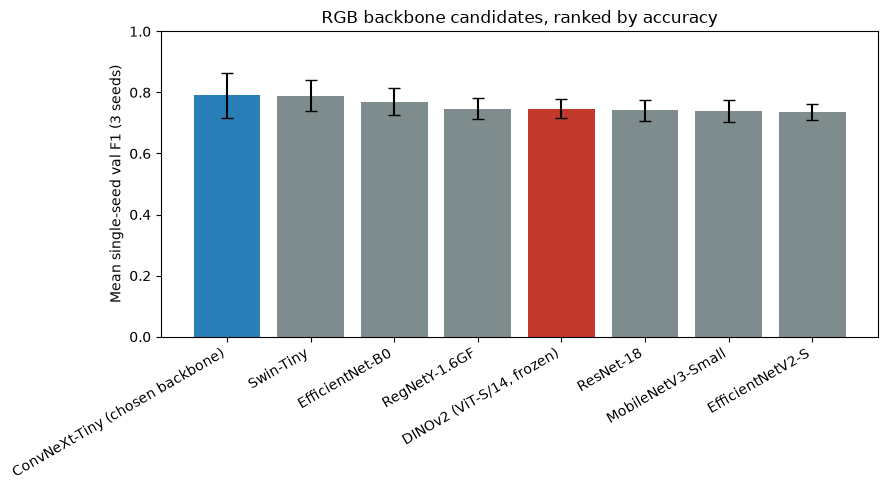

In [19]:
plot_df = results_df.dropna(subset=["val_f1_mean"]).copy()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#c0392b" if k == "dinov2" else "#2980b9" if k == "convnext_tiny" else "#7f8c8d"
          for k in plot_df["key"]]
ax.bar(plot_df["candidate"], plot_df["val_f1_mean"], yerr=plot_df["val_f1_std"], capsize=4, color=colors)
ax.set_ylabel("Mean single-seed val F1 (3 seeds)")
ax.set_title("RGB backbone candidates, ranked by accuracy")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(BENCH_OUT / "fig_ranked_accuracy.png", dpi=150)
plt.show()


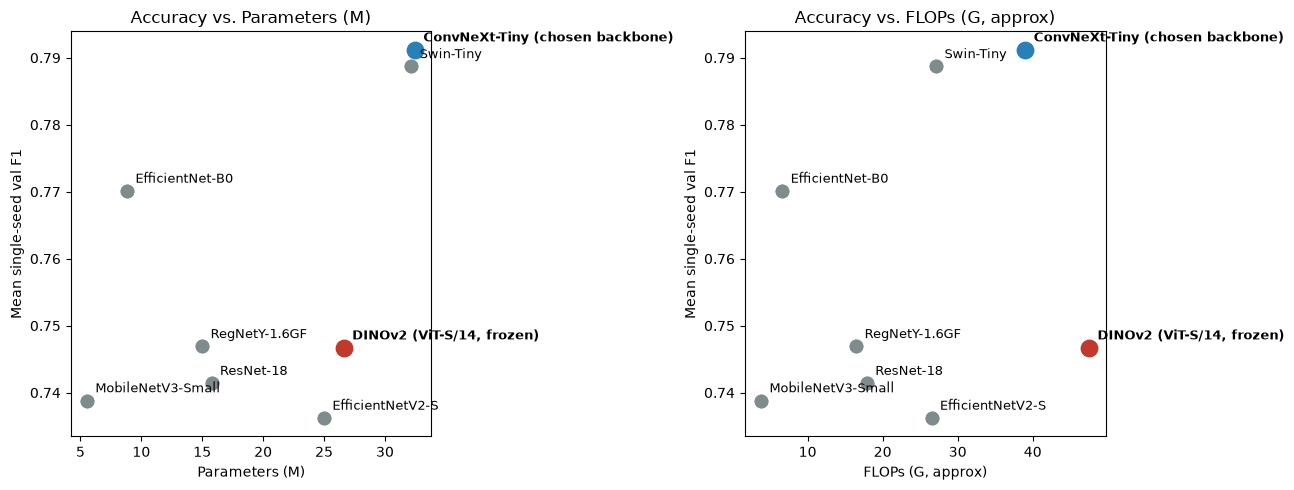

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, xcol, xlabel in [(axes[0], "params_m", "Parameters (M)"), (axes[1], "flops_g", "FLOPs (G, approx)")]:
    sub = plot_df.dropna(subset=[xcol])
    ax.scatter(sub[xcol], sub["val_f1_mean"], s=80, color="#7f8c8d", zorder=2)
    for _, row in sub.iterrows():
        highlight = row["key"] in ("dinov2", "convnext_tiny")
        color = "#c0392b" if row["key"] == "dinov2" else "#2980b9" if row["key"] == "convnext_tiny" else "#7f8c8d"
        ax.scatter([row[xcol]], [row["val_f1_mean"]], s=140 if highlight else 80, color=color, zorder=3)
        ax.annotate(row["candidate"], (row[xcol], row["val_f1_mean"]),
                    textcoords="offset points", xytext=(6, 6), fontsize=9,
                    fontweight="bold" if highlight else "normal")
    ax.set_xlabel(xlabel); ax.set_ylabel("Mean single-seed val F1")
    ax.set_title(f"Accuracy vs. {xlabel}")
plt.tight_layout()
plt.savefig(BENCH_OUT / "fig_accuracy_vs_cost.png", dpi=150)
plt.show()


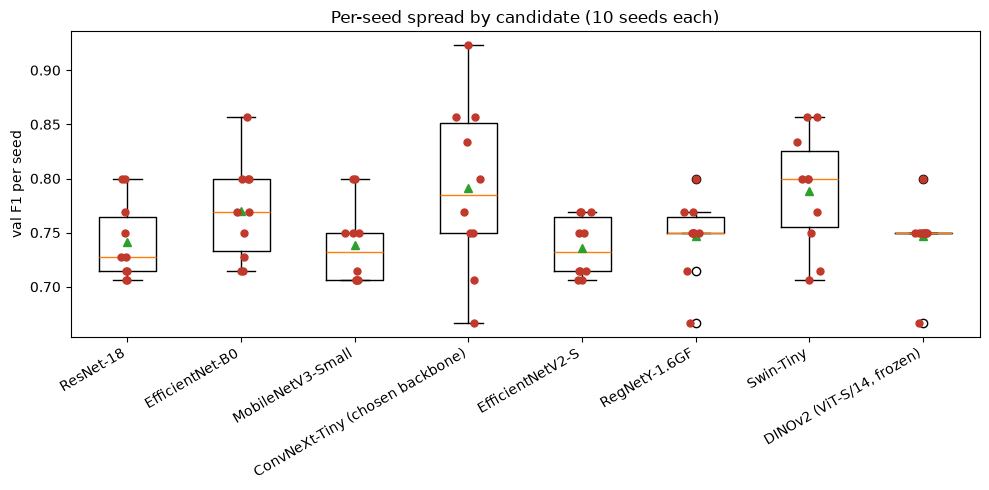

In [21]:
fig, ax = plt.subplots(figsize=(10, 5))
box_data = [[s["val_f1"] for s in RESULTS[k]["seed_results"]] for k in CANDIDATE_ORDER]
box_labels = [CANDIDATES[k]["label"] for k in CANDIDATE_ORDER]
bp = ax.boxplot(box_data, tick_labels=box_labels, showmeans=True)
for i, data in enumerate(box_data):
    x = np.random.normal(i + 1, 0.04, size=len(data))
    ax.scatter(x, data, color="#c0392b", zorder=3, s=25)
ax.set_ylabel("val F1 per seed")
ax.set_title(f"Per-seed spread by candidate ({len(SEEDS)} seeds each)")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig(BENCH_OUT / "fig_per_seed_spread.png", dpi=150)
plt.show()


## 12. SUmmary

In [22]:
dinov2_row = results_df[results_df["key"] == "dinov2"]
convnext_row = results_df[results_df["key"] == "convnext_tiny"]

print("=" * 90)
print("SUMMARY: accuracy vs. deployability trade-off")
print("=" * 90)

if dinov2_row.empty or dinov2_row["val_f1_mean"].isna().all():
    print("DINOv2: no successful result to report")
else:
    d = dinov2_row.iloc[0]
    rank = int((results_df["val_f1_mean"] > d["val_f1_mean"]).sum()) + 1
    print(f"DINOv2 (ViT-S/14, frozen): val F1 = {d['val_f1_mean']:.4f} (+/- {d['val_f1_std']:.4f}), "
          f"rank {rank} of {len(results_df)} on accuracy.")
    print(f"  Params: {d['params_m']} M | FLOPs: {d['flops_g']} G | Latency: {d['latency_ms']} ms/batch")

    if not convnext_row.empty and not convnext_row["val_f1_mean"].isna().all():
        c = convnext_row.iloc[0]
        f1_gap = d["val_f1_mean"] - c["val_f1_mean"]
        param_ratio = d["params_m"] / c["params_m"] if c["params_m"] else float("nan")
        print(f"\nConvNeXt-Tiny (chosen backbone): val F1 = {c['val_f1_mean']:.4f}, "
              f"{c['params_m']} M params, {c['flops_g']} G FLOPs, {c['latency_ms']} ms/batch")
        print(f"\nDINOv2 vs. ConvNeXt-Tiny: F1 delta = {f1_gap:+.4f}, "
              f"DINOv2 uses {param_ratio:.1f}x the parameters.")

print("\nFull ranked table:", BENCH_OUT / "backbone_benchmark_results.csv")
print("Figures saved to:", BENCH_OUT)


SUMMARY: accuracy vs. deployability trade-off
DINOv2 (ViT-S/14, frozen): val F1 = 0.7467 (+/- 0.0305), rank 5 of 8 on accuracy.
  Params: 26.63 M | FLOPs: 47.517 G | Latency: 40.0 ms/batch

ConvNeXt-Tiny (chosen backbone): val F1 = 0.7912, 32.47 M params, 39.026 G FLOPs, 38.0 ms/batch

DINOv2 vs. ConvNeXt-Tiny: F1 delta = -0.0445, DINOv2 uses 0.8x the parameters.

Full ranked table: /Users/sjanani2073/Desktop/convscript/runs/07_backbone_benchmark/backbone_benchmark_results.csv
Figures saved to: /Users/sjanani2073/Desktop/convscript/runs/07_backbone_benchmark


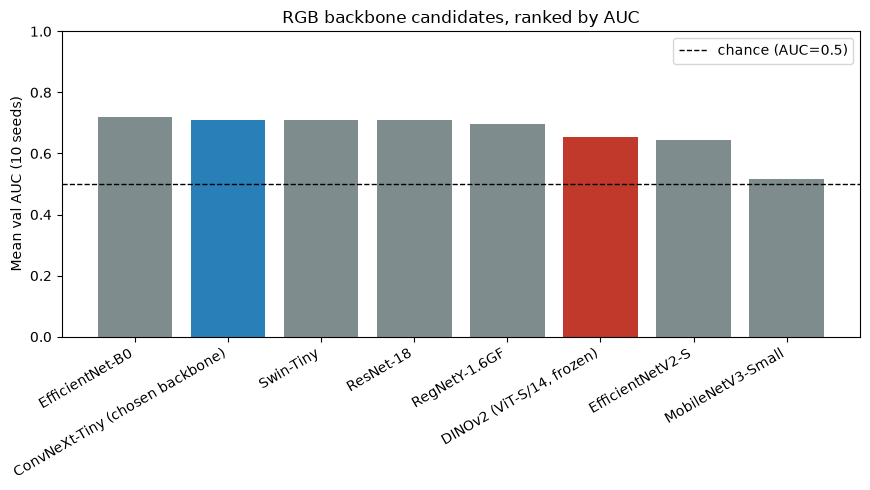

In [23]:
plot_df_auc = results_df.dropna(subset=["val_auc_mean"]).copy()
plot_df_auc = plot_df_auc.sort_values("val_auc_mean", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#c0392b" if k == "dinov2" else "#2980b9" if k == "convnext_tiny" else "#7f8c8d"
          for k in plot_df_auc["key"]]
ax.bar(plot_df_auc["candidate"], plot_df_auc["val_auc_mean"], color=colors)
ax.axhline(0.5, color="black", linestyle="--", linewidth=1, label="chance (AUC=0.5)")
ax.set_ylabel("Mean val AUC (10 seeds)")
ax.set_title("RGB backbone candidates, ranked by AUC")
ax.set_ylim(0, 1.0)
ax.legend()
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig(BENCH_OUT / "fig_ranked_auc.png", dpi=150)
plt.show()

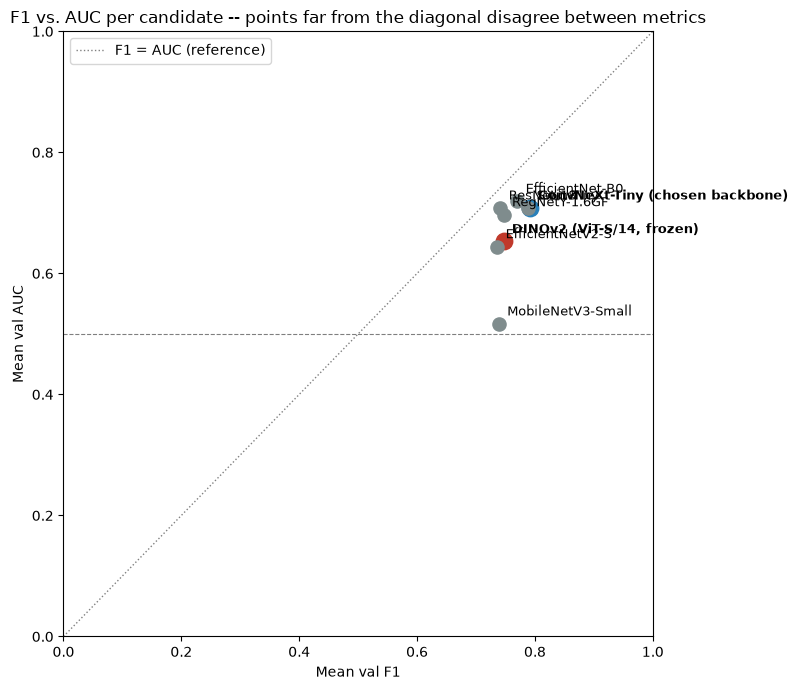

In [24]:
plot_df_both = results_df.dropna(subset=["val_f1_mean", "val_auc_mean"]).copy()

fig, ax = plt.subplots(figsize=(8, 7))
for _, row in plot_df_both.iterrows():
    highlight = row["key"] in ("dinov2", "convnext_tiny")
    color = "#c0392b" if row["key"] == "dinov2" else "#2980b9" if row["key"] == "convnext_tiny" else "#7f8c8d"
    ax.scatter([row["val_f1_mean"]], [row["val_auc_mean"]], s=140 if highlight else 90, color=color, zorder=3)
    ax.annotate(row["candidate"], (row["val_f1_mean"], row["val_auc_mean"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9,
                fontweight="bold" if highlight else "normal")
ax.plot([0, 1], [0, 1], color="gray", linestyle=":", linewidth=1, label="F1 = AUC (reference)")
ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Mean val F1"); ax.set_ylabel("Mean val AUC")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.set_title("F1 vs. AUC per candidate -- points far from the diagonal disagree between metrics")
ax.legend()
plt.tight_layout()
plt.savefig(BENCH_OUT / "fig_f1_vs_auc.png", dpi=150)
plt.show()

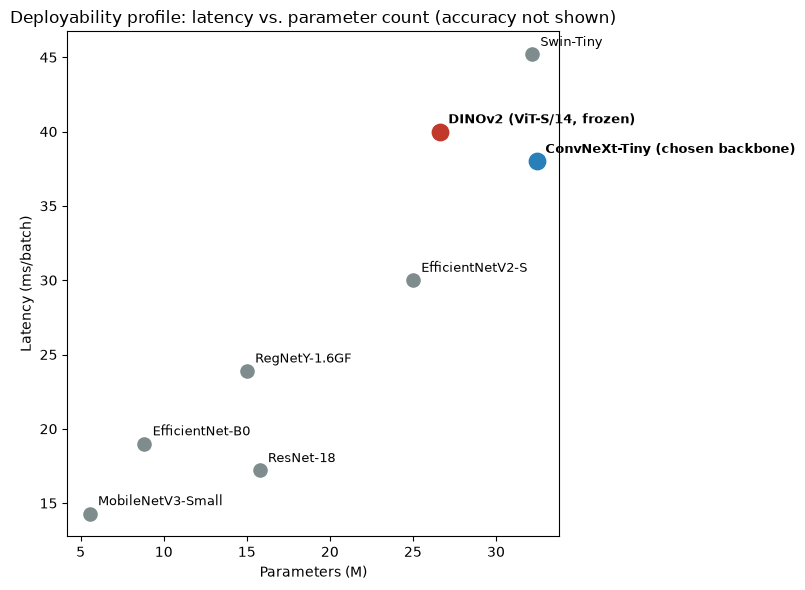

In [25]:
plot_df_cost = results_df.dropna(subset=["params_m", "latency_ms"]).copy()

fig, ax = plt.subplots(figsize=(8, 6))
for _, row in plot_df_cost.iterrows():
    highlight = row["key"] in ("dinov2", "convnext_tiny")
    color = "#c0392b" if row["key"] == "dinov2" else "#2980b9" if row["key"] == "convnext_tiny" else "#7f8c8d"
    ax.scatter([row["params_m"]], [row["latency_ms"]], s=140 if highlight else 90, color=color, zorder=3)
    ax.annotate(row["candidate"], (row["params_m"], row["latency_ms"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9,
                fontweight="bold" if highlight else "normal")
ax.set_xlabel("Parameters (M)"); ax.set_ylabel("Latency (ms/batch)")
ax.set_title("Deployability profile: latency vs. parameter count (accuracy not shown)")
plt.tight_layout()
plt.savefig(BENCH_OUT / "fig_latency_vs_params.png", dpi=150)
plt.show()

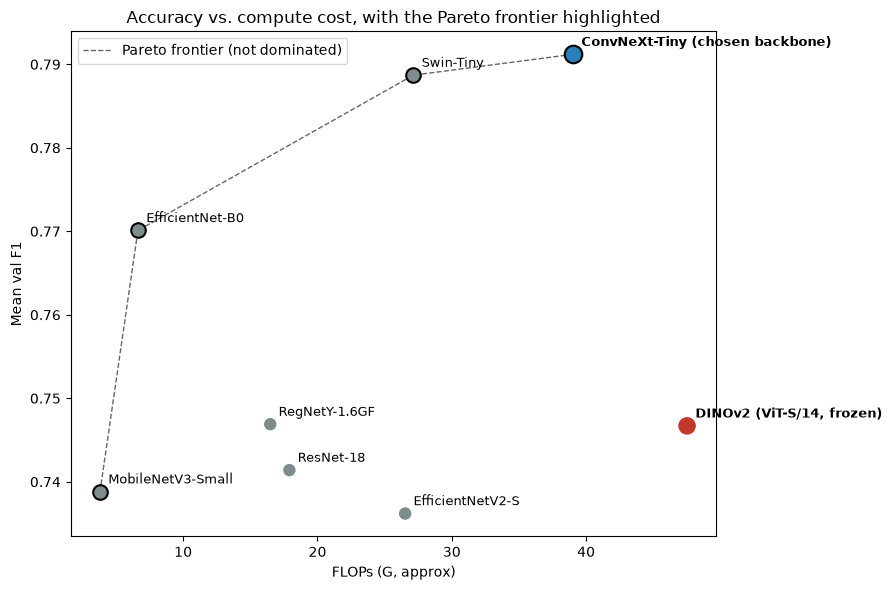

In [28]:
def pareto_frontier(df, cost_col, score_col):
    pts = df[[cost_col, score_col, "candidate", "key"]].dropna().sort_values(cost_col)
    frontier = []
    best_score_so_far = -np.inf
    for _, row in pts.iterrows():
        if row[score_col] > best_score_so_far:
            frontier.append(row)
            best_score_so_far = row[score_col]
    return pd.DataFrame(frontier)

plot_df_pareto = results_df.dropna(subset=["val_f1_mean", "flops_g"]).copy()
frontier_df = pareto_frontier(plot_df_pareto, "flops_g", "val_f1_mean")

fig, ax = plt.subplots(figsize=(9, 6))
for _, row in plot_df_pareto.iterrows():
    highlight = row["key"] in ("dinov2", "convnext_tiny")
    color = "#c0392b" if row["key"] == "dinov2" else "#2980b9" if row["key"] == "convnext_tiny" else "#7f8c8d"
    on_frontier = row["key"] in frontier_df["key"].values
    ax.scatter([row["flops_g"]], [row["val_f1_mean"]], s=160 if highlight else (110 if on_frontier else 80),
               color=color, zorder=3, edgecolors="black" if on_frontier else "none", linewidths=1.5)
    ax.annotate(row["candidate"], (row["flops_g"], row["val_f1_mean"]),
                textcoords="offset points", xytext=(6, 6), fontsize=9,
                fontweight="bold" if highlight else "normal")
frontier_sorted = frontier_df.sort_values("flops_g")
ax.plot(frontier_sorted["flops_g"], frontier_sorted["val_f1_mean"], color="black",
        linestyle="--", linewidth=1, alpha=0.6, label="Pareto frontier (not dominated)", zorder=2)
ax.set_xlabel("FLOPs (G, approx)"); ax.set_ylabel("Mean val F1")
ax.set_title("Accuracy vs. compute cost, with the Pareto frontier highlighted")
ax.legend()
plt.tight_layout()
plt.savefig(BENCH_OUT / "fig_pareto_frontier.png", dpi=150)
plt.show()

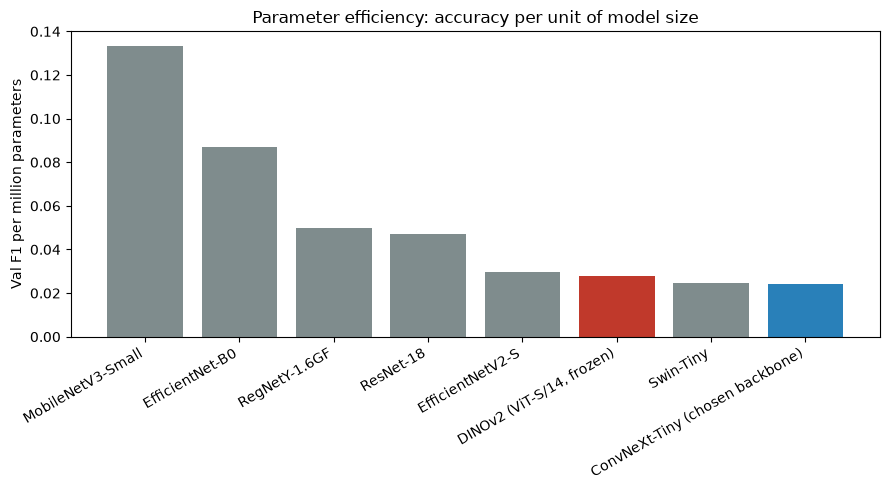

In [29]:
plot_df_eff = results_df.dropna(subset=["val_f1_mean", "params_m"]).copy()
plot_df_eff["f1_per_million_params"] = plot_df_eff["val_f1_mean"] / plot_df_eff["params_m"]
plot_df_eff = plot_df_eff.sort_values("f1_per_million_params", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#c0392b" if k == "dinov2" else "#2980b9" if k == "convnext_tiny" else "#7f8c8d"
          for k in plot_df_eff["key"]]
ax.bar(plot_df_eff["candidate"], plot_df_eff["f1_per_million_params"], color=colors)
ax.set_ylabel("Val F1 per million parameters")
ax.set_title("Parameter efficiency: accuracy per unit of model size")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig(BENCH_OUT / "fig_f1_per_param.png", dpi=150)
plt.show()

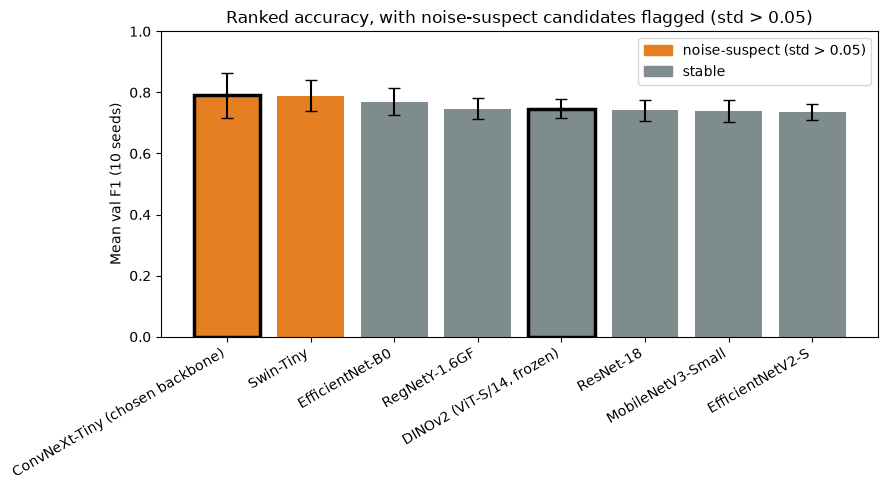

In [30]:
import matplotlib.patches as mpatches

plot_df_flagged = results_df.dropna(subset=["val_f1_mean"]).copy().sort_values("val_f1_mean", ascending=False)
colors = ["#e67e22" if flag else "#7f8c8d" for flag in plot_df_flagged["spread_noise_suspect"]]
edge_colors = ["black" if k in ("dinov2", "convnext_tiny") else "none" for k in plot_df_flagged["key"]]
edge_widths = [2.5 if k in ("dinov2", "convnext_tiny") else 0 for k in plot_df_flagged["key"]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(plot_df_flagged["candidate"], plot_df_flagged["val_f1_mean"], yerr=plot_df_flagged["val_f1_std"],
       capsize=4, color=colors, edgecolor=edge_colors, linewidth=edge_widths)
ax.set_ylabel("Mean val F1 (10 seeds)")
ax.set_title("Ranked accuracy, with noise-suspect candidates flagged (std > 0.05)")
ax.set_ylim(0, 1.0)
handles = [mpatches.Patch(color="#e67e22", label="noise-suspect (std > 0.05)"),
           mpatches.Patch(color="#7f8c8d", label="stable")]
ax.legend(handles=handles, loc="upper right")
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.savefig(BENCH_OUT / "fig_ranked_accuracy_flagged.png", dpi=150)
plt.show()